# Overlay analysis

Overlay analyses are GIS operations in which two or more vector layers are combined to produce new geometries. Typical overlay operations include union, intersection, and difference - named after the result of the combination of two layers.

In [2]:
import pathlib
NOTEBOOK_PATH = pathlib.Path().resolve()
DATA_DIRECTORY = NOTEBOOK_PATH / "data"

In [3]:
import geopandas

grid = geopandas.read_file(
    DATA_DIRECTORY
    / "helsinki_region_travel_times_to_railway_station"
    / "helsinki_region_travel_times_to_railway_station.gpkg"
)

helsinki = geopandas.read_file(
    DATA_DIRECTORY / "helsinki_municipality" / "helsinki_municipality.gpkg"
)

<Axes: >

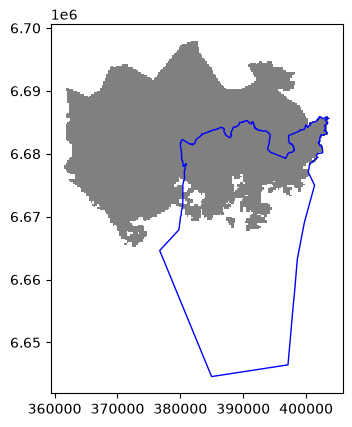

In [4]:
ax = grid.plot(facecolor="gray")
helsinki.plot(ax=ax, facecolor="None", edgecolor="blue")

Here the grey area is the Travel Time Matrix - a data set that contains 13231 grid squares (13231 rows of data) that covers the Helsinki region, and the blue area represents the municipality of Helsinki. Our goal is to conduct an overlay analysis and select the geometries from the grid polygon layer that intersect with the Helsinki municipality polygon.

When conducting overlay analysis, it is important to first check that the CRS of the layers match. The overlay visualization indicates that everything should be ok (the layers are plotted nicely on top of each other). However, let’s still check if the crs match using Python:



In [5]:
assert helsinki.crs == grid.crs, "CRS differs between layers!"

In [6]:
intersection = grid.overlay(helsinki, how="intersection")

<Axes: >

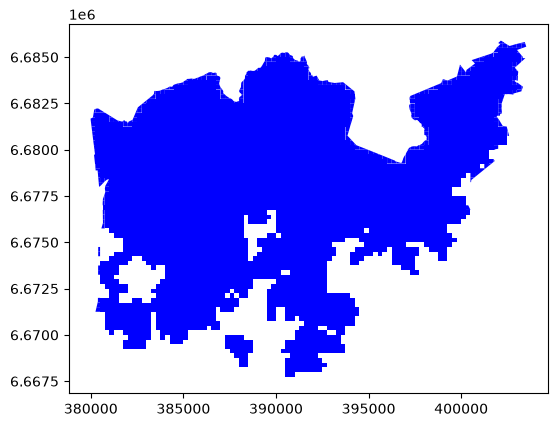

In [8]:
intersection.plot(color="b")

In [9]:
intersection.head()

,car_m_d,car_m_t,car_r_d,car_r_t,from_id,pt_m_d,pt_m_t,pt_m_tt,pt_r_d,pt_r_t,pt_r_tt,to_id,walk_d,walk_t,GML_ID,NAMEFIN,NAMESWE,NATCODE,geometry
0,29476,41,29483,46,5876274,29990,76,95,24984,77,99,5975375,25532,365,27517366,Helsinki,Helsingfors,091,"POLYGON ((402024.224 6685750, 402003.328 66857..."
1,29456,41,29462,46,5876275,29866,74,95,24860,75,93,5975375,25408,363,27517366,Helsinki,Helsingfors,091,"POLYGON ((402250 6685750, 402250 6685834.729, ..."
2,36772,50,36778,56,5876278,33541,116,137,44265,130,146,5975375,31110,444,27517366,Helsinki,Helsingfors,091,"POLYGON ((403148.515 6685750, 403243.781 66857..."
3,36898,49,36904,56,5876279,33720,119,141,44444,132,155,5975375,31289,447,27517366,Helsinki,Helsingfors,091,"POLYGON ((403250 6685750, 403250 6685774.119, ..."
4,29411,40,29418,44,5878128,29944,75,95,24938,76,99,5975375,25486,364,27517366,Helsinki,Helsingfors,091,"POLYGON ((401900.425 6685500, 402000 6685592.1..."


In [10]:
intersection.to_file(
    DATA_DIRECTORY / "intersection.gpkg",
    layer="travel_time_matrix_helsinki_region"
)